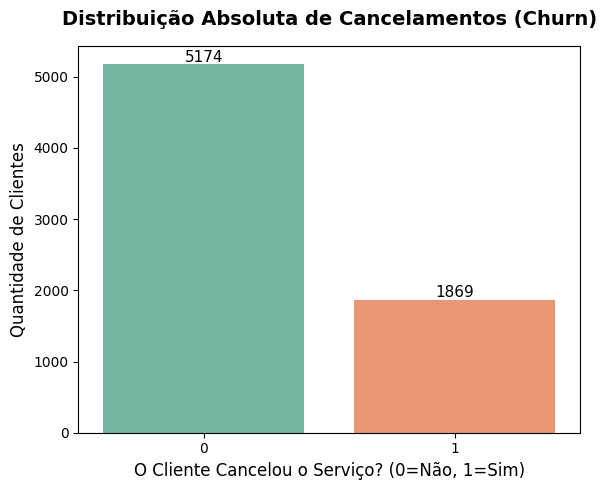

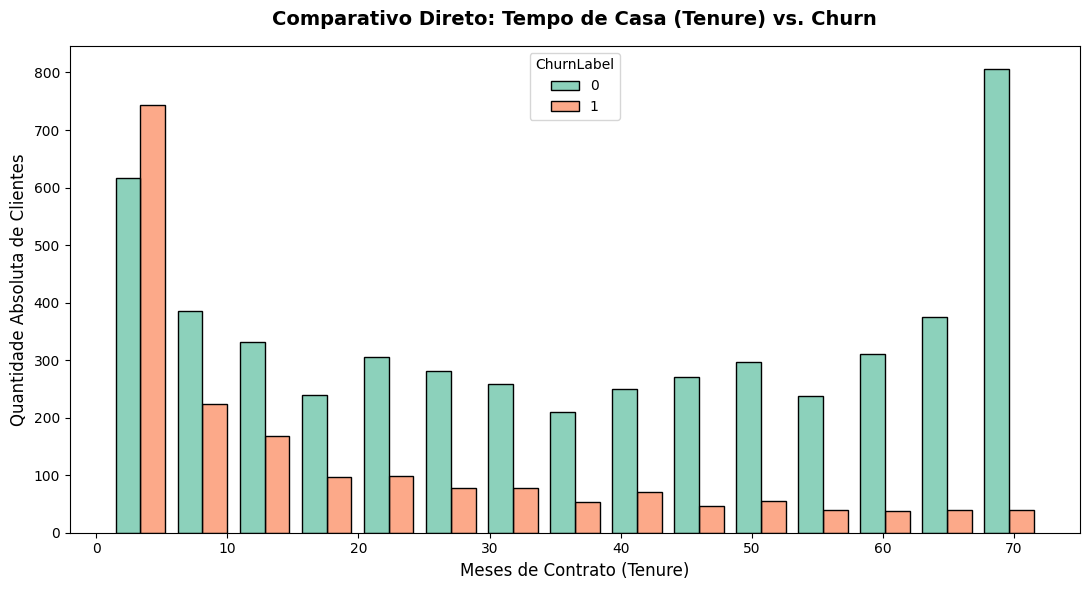

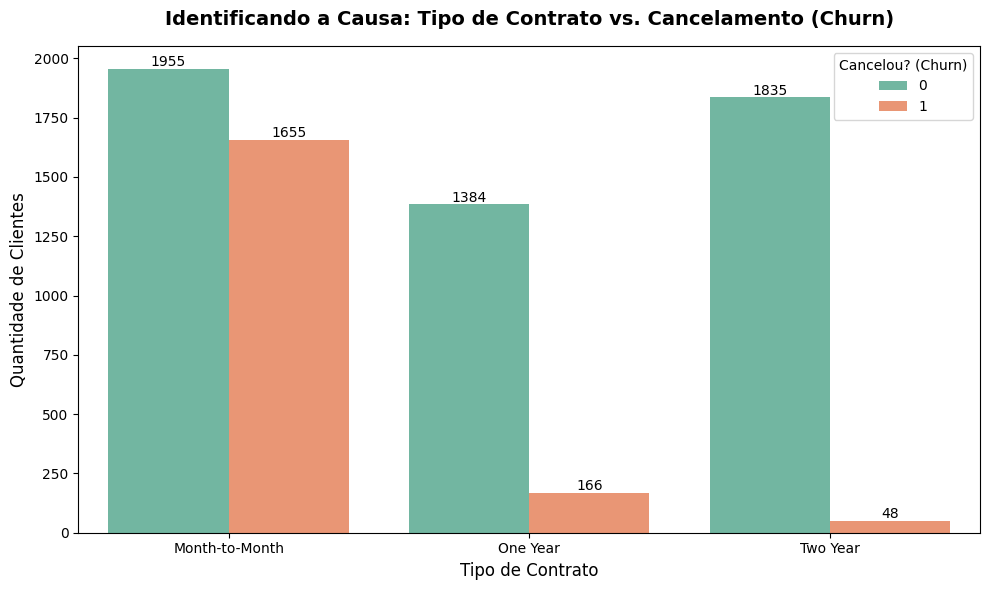

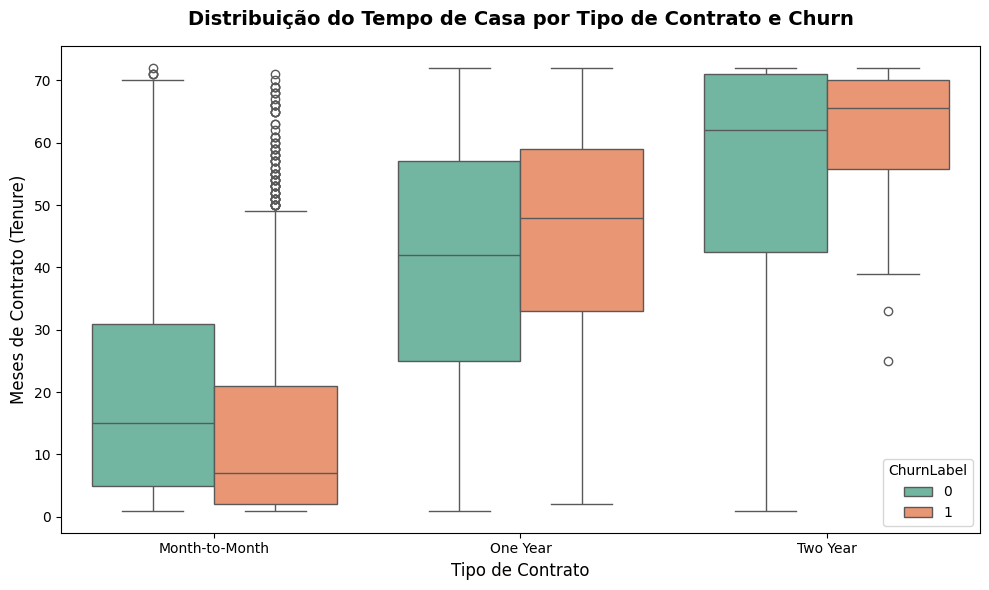

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# =========================================================================
# 1. CARREGAMENTO E SANEAMENTO DOS DADOS
# =========================================================================
sns.set_theme(style="whitegrid")
plt.style.use('default') # Garante fundo claro padrão para os plots

# Carregar o dataset
df = pd.read_csv('../data/raw/telco.csv')
df.columns = df.columns.str.replace(' ', '')

# Tratando os nulos com base na lógica de negócio
df['ChurnCategory'] = df['ChurnCategory'].fillna('None (Active Customer)')
df['ChurnReason'] = df['ChurnReason'].fillna('None (Active Customer)')
df['InternetType'] = df['InternetType'].fillna('No Internet Service')
df['Offer'] = df['Offer'].fillna('No Offer')

# Tratando a tipagem de TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Transformando a variável alvo 'ChurnLabel' em numérica (0 e 1)
df['ChurnLabel'] = df['ChurnLabel'].map({'Yes': 1, 'No': 0})

# =========================================================================
# 2. GRÁFICOS EXPLORATÓRIOS (PORTFÓLIO / BUSINESS INSIGHTS)
# =========================================================================

# Gráfico 1: Distribuição Absoluta de Cancelamentos (Churn)
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='ChurnLabel', data=df, hue='ChurnLabel', palette='Set2', legend=False)
plt.title('Distribuição Absoluta de Cancelamentos (Churn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('O Cliente Cancelou o Serviço? (0=Não, 1=Sim)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)
plt.tight_layout()
plt.show()

# Gráfico 2: Tempo de Casa (Tenure) vs. Churn
plt.figure(figsize=(11, 6))
sns.histplot(data=df, x='TenureinMonths', hue='ChurnLabel', multiple='dodge', palette='Set2', shrink=0.8)
plt.title('Comparativo Direto: Tempo de Casa (Tenure) vs. Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Meses de Contrato (Tenure)', fontsize=12)
plt.ylabel('Quantidade Absoluta de Clientes', fontsize=12)
plt.tight_layout()
plt.show()

# Gráfico 3: Tipo de Contrato vs. Cancelamento
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Contract', hue='ChurnLabel', palette='Set2')
plt.title('Identificando a Causa: Tipo de Contrato vs. Cancelamento (Churn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
plt.legend(title='Cancelou? (Churn)', loc='best')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()

# Gráfico 4: Boxplot de Distribuição do Tempo por Contrato
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Contract', y='TenureinMonths', hue='ChurnLabel', palette='Set2')
plt.title('Distribuição do Tempo de Casa por Tipo de Contrato e Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Meses de Contrato (Tenure)', fontsize=12)
plt.tight_layout()
plt.show()



In [2]:
# =========================================================================
# 3. PREPARAÇÃO MATRICIAL E NORMALIZAÇÃO PARA O SOM
# =========================================================================
colunas_comportamentais = [
    'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married', 'Dependents', 'NumberofDependents', 
    'ReferredaFriend', 'NumberofReferrals', 'TenureinMonths', 'Offer', 'PhoneService', 
    'AvgMonthlyLongDistanceCharges', 'MultipleLines', 'InternetService', 'InternetType', 
    'AvgMonthlyGBDownload', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 
    'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 
    'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 
    'SatisfactionScore', 'CLTV'
]

X_raw = df[colunas_comportamentais].copy()
y = df['ChurnLabel'].values

# Garantindo amostras limpas e válidas
linhas_validas = ~pd.isna(y)
X_raw_clean = X_raw[linhas_validas]
y_clean = y[linhas_validas].astype(int)

# Encoding e Escalonamento
colunas_categoricas = X_raw_clean.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X_raw_clean, columns=colunas_categoricas, drop_first=True)

scaler = MinMaxScaler()
X_scaled_clean = scaler.fit_transform(X_encoded)




--- Treinando o Mapa de Kohonen (5000 iterações) ---
Treinamento do Kohonen concluído!


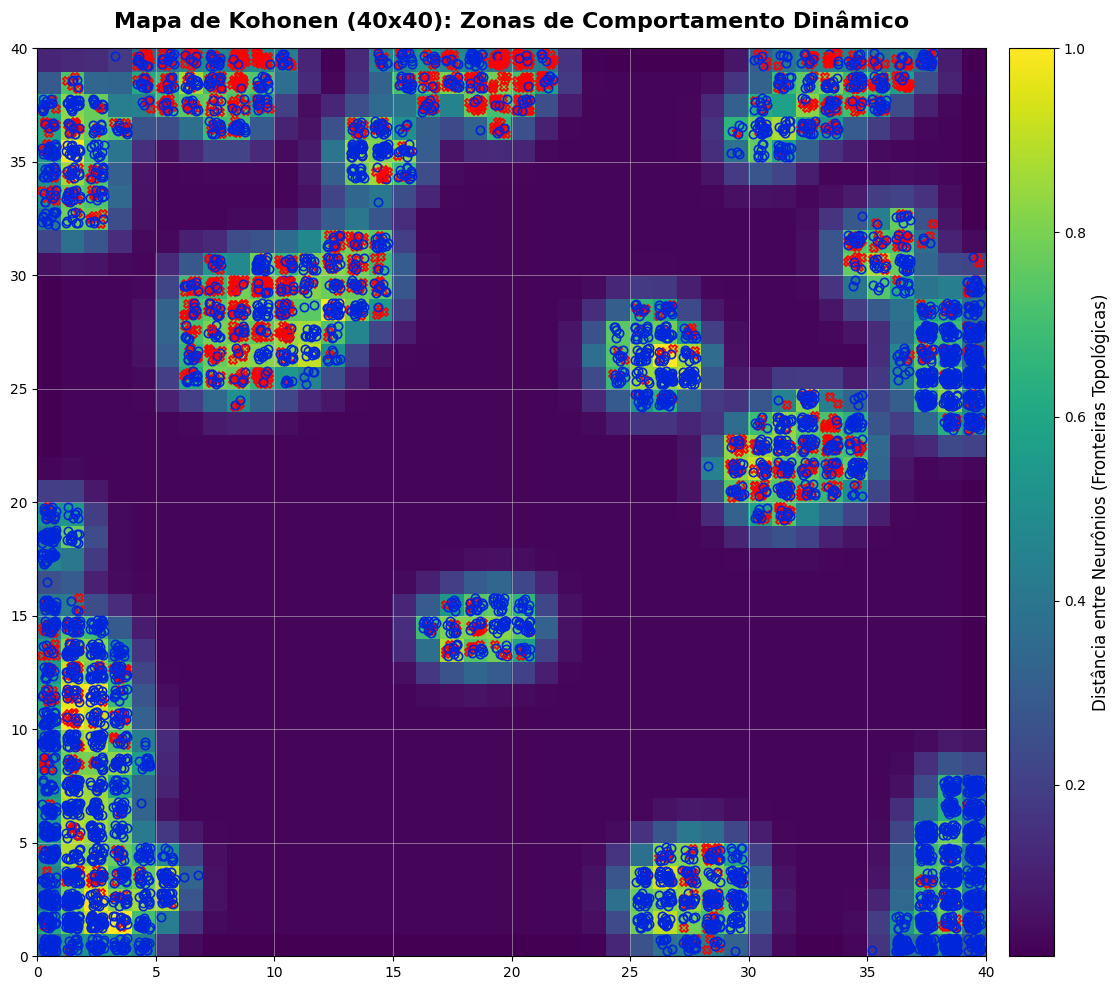

In [3]:
# =========================================================================
# 4. TREINAMENTO E PLOTAGEM DO MAPA DE KOHONEN (U-MATRIX)
# =========================================================================
tamanho_x = 40
tamanho_y = 40
input_len = X_scaled_clean.shape[1]

som = MiniSom(x=tamanho_x, y=tamanho_y, input_len=input_len, 
              sigma=0.70, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
som.pca_weights_init(X_scaled_clean)

print("\n--- Treinando o Mapa de Kohonen (5000 iterações) ---")
som.train_random(data=X_scaled_clean, num_iteration=5000, verbose=False)
print("Treinamento do Kohonen concluído!")

# Gráfico 5: A U-Matrix de Alta Resolução com os Clientes Mapeados
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.pcolor(som.distance_map().T, cmap='viridis') 
cbar = fig.colorbar(cax, ax=ax, pad=0.02)
cbar.set_label('Distância entre Neurônios (Fronteiras Topológicas)', fontsize=12)

markers = ['o', 'X']
colors = ['#0026db', '#ff0000'] # Azul escuro para Ativo, Vermelho vivo para Churn
rng = np.random.default_rng(42)

for i, x in enumerate(X_scaled_clean):
    w = som.winner(x)
    deslocamento_x = rng.uniform(-0.3, 0.3)
    deslocamento_y = rng.uniform(-0.3, 0.3)
    ax.plot(w[0] + 0.5 + deslocamento_x, w[1] + 0.5 + deslocamento_y, markers[y_clean[i]], 
            markerfacecolor='none', markeredgecolor=colors[y_clean[i]], 
            markersize=6, markeredgewidth=1.2)

ax.set_title('Mapa de Kohonen (40x40): Zonas de Comportamento Dinâmico', fontsize=16, fontweight='bold', pad=15)
ax.set_xlim(0, tamanho_x)
ax.set_ylim(0, tamanho_y)
ax.grid(True, which='both', color='#d3d3d3', linestyle='-', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()



In [4]:
# =========================================================================
# 5. ACOPLAMENTO HÍBRIDO E ENGENHARIA DE FEATURES NO PERFIL NORTE
# =========================================================================
df_analise = df[linhas_validas].copy()
coordenadas_bmu = [som.winner(x) for x in X_scaled_clean]
df_analise['X_som'] = [p[0] for p in coordenadas_bmu]
df_analise['Y_som'] = [p[1] for p in coordenadas_bmu]

# Isolando o hemisfério norte de risco
regiao_norte = df_analise[df_analise['Y_som'] >= 20].copy()
print(f"\nTotal de clientes isolados no Perfil Norte (Y >= 20): {regiao_norte.shape[0]}")

# Engenharia Cirúrgica local
regiao_norte['San_Diego_Effect'] = np.where(regiao_norte['City'] == 'San Diego', 1, 0)




Total de clientes isolados no Perfil Norte (Y >= 20): 4051


In [5]:
print("=================== DIAGNÓSTICO DE ENGENHARIA REVERSA (PERFIL NORTE) ===================")

# Filtrando apenas quem de fato cancelou (Churned) dentro da região norte para entender o comportamento
df_churn_norte = regiao_norte[regiao_norte['CustomerStatus'] == 'Churned']
df_stayed_norte = regiao_norte[regiao_norte['CustomerStatus'] == 'Stayed']

print(f"Total de Clientes no Norte: {regiao_norte.shape[0]}")
print(f"Total de Cancelamentos no Norte: {df_churn_norte.shape[0]} ({df_churn_norte.shape[0]/regiao_norte.shape[0]*100:.2f}%)\n")

# 1. Análise dos Motivos de Churn
print("--- 1. Principais Motivos de Churn no Perfil Norte (Top 5) ---")
print(df_churn_norte['ChurnReason'].value_counts().head(5))
print("\n" + "-"*50 + "\n")

# 2. Análise de Preço (Bolso)
print("--- 2. Comparativo de Cobrança Mensal (MonthlyCharge) ---")
print(f"Média de quem CANCELOU no Norte: ${df_churn_norte['MonthlyCharge'].mean():.2f}")
print(f"Média de quem FICOU no Norte:    ${df_stayed_norte['MonthlyCharge'].mean():.2f}")
print(f"Mediana de quem CANCELOU no Norte: ${df_churn_norte['MonthlyCharge'].median():.2f}")
print("\n" + "-"*50 + "\n")

# 3. Análise Cruzada de Ofertas
print("--- 3. Distribuição de Ofertas entre os Cancelados do Norte ---")
print(df_churn_norte['Offer'].value_counts())

=================== DIAGNÓSTICO DE ENGENHARIA REVERSA (PERFIL NORTE) ===================
Total de Clientes no Norte: 4051
Total de Cancelamentos no Norte: 1545 (38.14%)

--- 1. Principais Motivos de Churn no Perfil Norte (Top 5) ---
ChurnReason
Competitor had better devices    265
Competitor made better offer     262
Attitude of support person       185
Don't know                       102
Competitor offered more data      91
Name: count, dtype: int64

--------------------------------------------------

--- 2. Comparativo de Cobrança Mensal (MonthlyCharge) ---
Média de quem CANCELOU no Norte: $75.05
Média de quem FICOU no Norte:    $63.16
Mediana de quem CANCELOU no Norte: $79.60

--------------------------------------------------

--- 3. Distribuição de Ofertas entre os Cancelados do Norte ---
Offer
No Offer    873
Offer E     390
Offer D     147
Offer C      80
Offer B      47
Offer A       8
Name: count, dtype: int64


In [6]:
print("--- 1. Isolando e Tratando a Matriz de Recursos Focada ---")

# Criando a estrutura exatamente com a sua seleção de variáveis
df_statistics = regiao_norte[['CustomerStatus', 'MonthlyCharge', 'DeviceProtectionPlan', 'PremiumTechSupport', 'UnlimitedData']].copy()

# Separando a matriz preditora (tirando o status para evitar vazamento no agrupamento)
features_servico = ['DeviceProtectionPlan', 'PremiumTechSupport', 'UnlimitedData']
X_focado = df_statistics[['MonthlyCharge']].copy()

# Convertendo os serviços de texto para numérico puro (Yes=1, qualquer outra coisa=0)
for col in features_servico:
    X_focado[col] = np.where(df_statistics[col] == 'Yes', 1, 0)

# Aplicando o StandardScaler para equilibrar o peso do preço com os binários de serviço
scaler_dbscan = StandardScaler()
X_focado_scaled = scaler_dbscan.fit_transform(X_focado)

print("--- 2. Executando o DBSCAN para Mapear as Ilhas ---")
# eps=0.8 e min_samples=15 são ótimos parâmetros iniciais para esse volume de dimensões comprimido
dbscan_focado = DBSCAN(eps=0.70, min_samples=15)
df_statistics['Ilha_DBSCAN'] = dbscan_focado.fit_predict(X_focado_scaled)

# 3. Gerando o Relatório Anatômico das Ilhas Encontradas
print("\n=================== ANATOMIA DAS ILHAS DE SERVIÇO E PAGAMENTO ===================")

# Montando um dataframe temporário de análise agregada
df_analise_ilhas = X_focado.copy()
df_analise_ilhas['Ilha'] = df_statistics['Ilha_DBSCAN']
df_analise_ilhas['Is_Churn'] = np.where(df_statistics['CustomerStatus'] == 'Churned', 1, 0)

# Agrupando por ilha para ver a média de preço, adoção de serviços e taxa real de cancelamento
relatorio_ilhas = df_analise_ilhas.groupby('Ilha').agg(
    Total_Clientes=('MonthlyCharge', 'count'),
    Media_Preco_Mensal=('MonthlyCharge', 'mean'),
    Adocao_Protecao_Disp=('DeviceProtectionPlan', 'mean'),
    Adocao_Suporte_Premium=('PremiumTechSupport', 'mean'),
    Adocao_Dados_Ilimitados=('UnlimitedData', 'mean'),
    Taxa_Real_de_Churn=('Is_Churn', 'mean')
).reset_index()

# Formatando as taxas em percentual para facilitar a leitura visual no console
colunas_taxa = [c for c in relatorio_ilhas.columns if 'Adocao' in c or 'Taxa' in c]
for col in colunas_taxa:
    relatorio_ilhas[col] = (relatorio_ilhas[col] * 100).round(1).astype(str) + '%'

relatorio_ilhas['Media_Preco_Mensal'] = relatorio_ilhas['Media_Preco_Mensal'].round(2)

# Nota de engenharia: a Ilha -1 guarda os clientes com comportamentos dispersos (ruído)
print(relatorio_ilhas.to_string(index=False))

--- 1. Isolando e Tratando a Matriz de Recursos Focada ---
--- 2. Executando o DBSCAN para Mapear as Ilhas ---

=================== ANATOMIA DAS ILHAS DE SERVIÇO E PAGAMENTO ===================
 Ilha  Total_Clientes  Media_Preco_Mensal Adocao_Protecao_Disp Adocao_Suporte_Premium Adocao_Dados_Ilimitados Taxa_Real_de_Churn
   -1               1               29.50               100.0%                   0.0%                    0.0%             100.0%
    0            1572               71.27                 0.0%                   0.0%                  100.0%              52.2%
    1             619               84.21               100.0%                   0.0%                  100.0%              43.5%
    2              89               83.58               100.0%                   0.0%                    0.0%              40.4%
    3             941               34.07                 0.0%                   0.0%                    0.0%              23.0%
    4             389           

In [7]:
print("=================== LABORATÓRIO DE SUB-CLUSTERIZAÇÃO EXPANDIDA ===================")

# 1. Selecionando o ecossistema completo de serviços + Preço
todos_servicos = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 
    'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 
    'StreamingMusic', 'UnlimitedData'
]

df_statistics_exp = regiao_norte[['CustomerStatus', 'MonthlyCharge'] + todos_servicos].copy()

# Isolando a matriz preditora e convertendo TODOS os serviços para binário puro
X_expandido = df_statistics_exp[['MonthlyCharge']].copy()
for col in todos_servicos:
    X_expandido[col] = np.where(df_statistics_exp[col] == 'Yes', 1, 0)

# Aplicando o StandardScaler (fundamental para manter o equilíbrio de pesos com o preço)
scaler_dbscan_exp = StandardScaler()
X_expandido_scaled = scaler_dbscan_exp.fit_transform(X_expandido)

# 2. Executando o DBSCAN no espaço expandido
# Como aumentamos as dimensões (de 4 para 9), subimos levemente o eps para 1.2 para o algoritmo conseguir conectar os pontos
dbscan_expandido = DBSCAN(eps=2.253, min_samples=10)
df_statistics_exp['Ilha_Expandida'] = dbscan_expandido.fit_predict(X_expandido_scaled)

# 3. Construindo o Relatório de Anatomia das Novas Ilhas
df_analise_exp = X_expandido.copy()
df_analise_exp['Ilha'] = df_statistics_exp['Ilha_Expandida']
df_analise_exp['Is_Churn'] = np.where(df_statistics_exp['CustomerStatus'] == 'Churned', 1, 0)

# Dicionário de agregação dinâmico para calcular a média de adoção de cada serviço automaticamente
agregacoes = {
    'MonthlyCharge': ['count', 'mean'],
    'Is_Churn': 'mean'
}
for col in todos_servicos:
    agregacoes[col] = 'mean'

relatorio_exp = df_analise_exp.groupby('Ilha').agg(agregacoes)

# Ajustando os nomes das colunas para o print ficar limpo
relatorio_exp.columns = [
    'Total_Clientes', 'Media_Preco', 'Taxa_Churn'
] + [f'Adocao_{c}' for c in todos_servicos]

# Formatando para exibição em percentual
cols_percentual = [c for c in relatorio_exp.columns if 'Adocao' in c or 'Taxa' in c]
for col in cols_percentual:
    relatorio_exp[col] = (relatorio_exp[col] * 100).round(1).astype(str) + '%'

relatorio_exp['Media_Preco'] = relatorio_exp['Media_Preco'].round(2)

print("\n--- Relatório das Ilhas do Ecossistema de Serviços Expandido ---")
print(relatorio_exp.reset_index().to_string(index=False))

=================== LABORATÓRIO DE SUB-CLUSTERIZAÇÃO EXPANDIDA ===================

--- Relatório das Ilhas do Ecossistema de Serviços Expandido ---
 Ilha  Total_Clientes  Media_Preco Taxa_Churn Adocao_OnlineSecurity Adocao_OnlineBackup Adocao_DeviceProtectionPlan Adocao_PremiumTechSupport Adocao_StreamingTV Adocao_StreamingMovies Adocao_StreamingMusic Adocao_UnlimitedData
   -1               1        96.30     100.0%                100.0%                0.0%                      100.0%                    100.0%               0.0%                 100.0%                  0.0%                 0.0%
    0             350        75.37      48.0%                  0.0%              100.0%                        0.0%                      0.0%              38.9%                  37.7%                 34.9%                86.3%
    1            1824        51.27      41.5%                  0.0%                0.0%                        0.0%                      0.0%              19.1%          

In [8]:
print("=================== LABORATÓRIO: DBSCAN ESPECIALISTA EM INTERNET ===================")

# =========================================================================
# CONTROLE DE PARÂMETROS DO DBSCAN (Sinta-se livre para alterar e rodar)
# =========================================================================
PARAM_EPS = 1.65        # Raio de distância geométrica
PARAM_MIN_SAMPLES = 30   # Mínimo de clientes para consolidar uma ilha de internet

# 1. ISOLAMENTO DE POPULAÇÃO: Filtrando apenas clientes que possuem Internet ativa no Norte
# Isso remove a "distração" dos clientes de telefone puro de 20 dólares
df_internet_norte = regiao_norte[regiao_norte['InternetService'] == 'Yes'].copy()

# Variáveis alvo para entender o comportamento de streaming, ciclo de vida e preços
features_interesse = [
    'CustomerStatus', 'TenureinMonths', 'MonthlyCharge', 'Contract',
    'StreamingTV', 'StreamingMovies', 'StreamingMusic'
]

df_segmentado = df_internet_norte[features_interesse].copy()

# 2. Binarização e Tratamento da Tipagem
colunas_streaming = ['StreamingTV', 'StreamingMovies', 'StreamingMusic']
for col in colunas_streaming:
    df_segmentado[col] = np.where(df_segmentado[col] == 'Yes', 1, 0)

# One-Hot Encoding apenas nos tipos de Contrato
df_seg_encoded = pd.get_dummies(df_segmentado, columns=['Contract'], drop_first=False)

# Isolando os recursos que vão guiar o algoritmo (removendo a resposta de Churn)
recursos_cluster = [c for c in df_seg_encoded.columns if c != 'CustomerStatus']
X_seg = df_seg_encoded[recursos_cluster].copy()

# Padronizando para equilibrar dólares, meses e flags de streaming/contrato
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

# 3. Executando o DBSCAN no Universo de Internet
dbscan_internet = DBSCAN(eps=PARAM_EPS, min_samples=PARAM_MIN_SAMPLES)
df_segmentado['Ilha_Internet_Foco'] = dbscan_internet.fit_predict(X_seg_scaled)

# 4. Construindo o Relatório de Anatomia das Novas Ilhas de Internet
df_analise_seg = X_seg.copy()
df_analise_seg['Ilha'] = df_segmentado['Ilha_Internet_Foco']
df_analise_seg['Is_Churn'] = np.where(df_segmentado['CustomerStatus'] == 'Churned', 1, 0)

# Montando a agregação dinâmica das colunas
dict_agg_seg = {
    'Is_Churn': ['count', 'mean'],
    'TenureinMonths': 'mean',
    'MonthlyCharge': 'mean'
}

colunas_dummies_restantes = [c for c in recursos_cluster if c not in ['TenureinMonths', 'MonthlyCharge']]
for col in colunas_dummies_restantes:
    dict_agg_seg[col] = 'mean'

relatorio_seg = df_analise_seg.groupby('Ilha').agg(dict_agg_seg)

# Renomeando as colunas de forma amigável
nomes_finais = ['Total_Clientes', 'Taxa_Churn', 'Media_Tenure', 'Media_Preco'] + [f'Média_{c}' for c in colunas_dummies_restantes]
relatorio_seg.columns = nomes_finais

# Passando taxas e médias binárias para string percentual (%)
cols_pct = [c for c in relatorio_seg.columns if 'Taxa' in c or 'Média_' in c]
for col in cols_pct:
    relatorio_seg[col] = (relatorio_seg[col] * 100).round(1).astype(str) + '%'

relatorio_seg['Media_Tenure'] = relatorio_seg['Media_Tenure'].round(1)
relatorio_seg['Media_Preco'] = relatorio_seg['Media_Preco'].round(2)

print(f"\n[Foco: Clientes de Internet] EPS: {PARAM_EPS} | MIN_SAMPLES: {PARAM_MIN_SAMPLES}")
print(f"Clientes de Internet Alocados: {df_segmentado[df_segmentado['Ilha_Internet_Foco'] != -1].shape[0]}")
print(f"Clientes de Internet Tratados como Ruído (Ilha -1): {df_segmentado[df_segmentado['Ilha_Internet_Foco'] == -1].shape[0]}")
print("\n--- ANATOMIA DAS ILHAS EXCLUSIVAS DE INTERNET ---")
print(relatorio_seg.reset_index().sort_values(by='Total_Clientes', ascending=False).to_string(index=False))

=================== LABORATÓRIO: DBSCAN ESPECIALISTA EM INTERNET ===================

[Foco: Clientes de Internet] EPS: 1.65 | MIN_SAMPLES: 30
Clientes de Internet Alocados: 3211
Clientes de Internet Tratados como Ruído (Ilha -1): 154

--- ANATOMIA DAS ILHAS EXCLUSIVAS DE INTERNET ---
 Ilha  Total_Clientes Taxa_Churn  Media_Tenure  Media_Preco Média_StreamingTV Média_StreamingMovies Média_StreamingMusic Média_Contract_Month-to-Month Média_Contract_One Year Média_Contract_Two Year
    0            1096      49.3%          12.4        62.50              0.0%                  0.0%                 0.0%                        100.0%                    0.0%                    0.0%
    1             500      58.4%          22.4        92.44            100.0%                100.0%               100.0%                        100.0%                    0.0%                    0.0%
    3             326      48.5%          16.9        77.18              0.0%                100.0%               100

In [9]:
print("=================== LABORATÓRIO: METODOLOGIA PLUS-MINUS (±) DE ILHA ===================")

df_norte_laboratorio = regiao_norte.copy()

# 1. Puxando com segurança a coluna gerada no bloco do DBSCAN Expandido
# Usamos o index para garantir o alinhamento perfeito das linhas filtradas do Norte
df_norte_laboratorio['Ilha_Expandida'] = df_statistics_exp['Ilha_Expandida']

# 2. Mapear a média de preço real de cada Ilha Expandida
mapa_medias_ilhas = df_norte_laboratorio.groupby('Ilha_Expandida')['MonthlyCharge'].mean().to_dict()

# 3. Calcular o Saldo de Custo Absoluto do Cliente em relação à sua Ilha (Price_Plus_Minus)
df_norte_laboratorio['Island_Mean_Price'] = df_norte_laboratorio['Ilha_Expandida'].map(mapa_medias_ilhas)
df_norte_laboratorio['Price_Plus_Minus'] = df_norte_laboratorio['MonthlyCharge'] - df_norte_laboratorio['Island_Mean_Price']

# 4. Criar o Amortecedor de Serviços (Service Cushion)
# Usando variáveis temporárias para não corromper as colunas categóricas originais
cushion_suporte = np.where(df_norte_laboratorio['PremiumTechSupport'] == 'Yes', -5.0, 0.0)
cushion_protecao = np.where(df_norte_laboratorio['DeviceProtectionPlan'] == 'Yes', -3.0, 0.0)
cushion_dados = np.where(df_norte_laboratorio['UnlimitedData'] == 'Yes', -1.0, 0.0)

# O amortecedor final de engajamento
df_norte_laboratorio['Service_Cushion'] = cushion_suporte + cushion_protecao + cushion_dados

# 5. A Super-Feature Final: Plus-Minus Combinado (Conceito de saldo relativo)
df_norte_laboratorio['Island_Plus_Minus_Index'] = df_norte_laboratorio['Price_Plus_Minus'] + df_norte_laboratorio['Service_Cushion']

# 6. Mantendo o modificador regional geográfico
df_norte_laboratorio['San_Diego_Effect'] = np.where(df_norte_laboratorio['City'] == 'San Diego', 1, 0)

print("Feature 'Island_Plus_Minus_Index' construída e amarrada com sucesso!")
print("\nVerificando o comportamento médio do Plus-Minus por Status Real:")
print(df_norte_laboratorio.groupby('CustomerStatus')['Island_Plus_Minus_Index'].mean())

# Sincronizando e dropando a coluna temporária da ilha para ela não vazar na árvore do XGBoost
regiao_norte = df_norte_laboratorio.drop(columns=['Ilha_Expandida'])

=================== LABORATÓRIO: METODOLOGIA PLUS-MINUS (±) DE ILHA ===================
Feature 'Island_Plus_Minus_Index' construída e amarrada com sucesso!

Verificando o comportamento médio do Plus-Minus por Status Real:
CustomerStatus
Churned     7.711158
Joined    -14.565378
Stayed     -7.800570
Name: Island_Plus_Minus_Index, dtype: float64



=================== PERFORMANCE DO MODELO FINAL EVOLUÍDO ===================
Melhores parâmetros: {'gamma': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
ROC-AUC Atualizado: 86.92%
RECALL Atualizado: 83.41%
PRECISÃO Atualizada: 68.25%

Nova Matriz de Confusão:
  [Clientes do Norte que FICARAM previstos corretamente]: 572
  [Clientes do Norte que FICARAM mas gerou Alarme Falso]: 180
  [Clientes do Norte que REALMENTE CANCELARAM e cometeu Erro Crítico]: 77
  [Clientes do Norte que REALMENTE CANCELARAM previstos corretamente]: 387


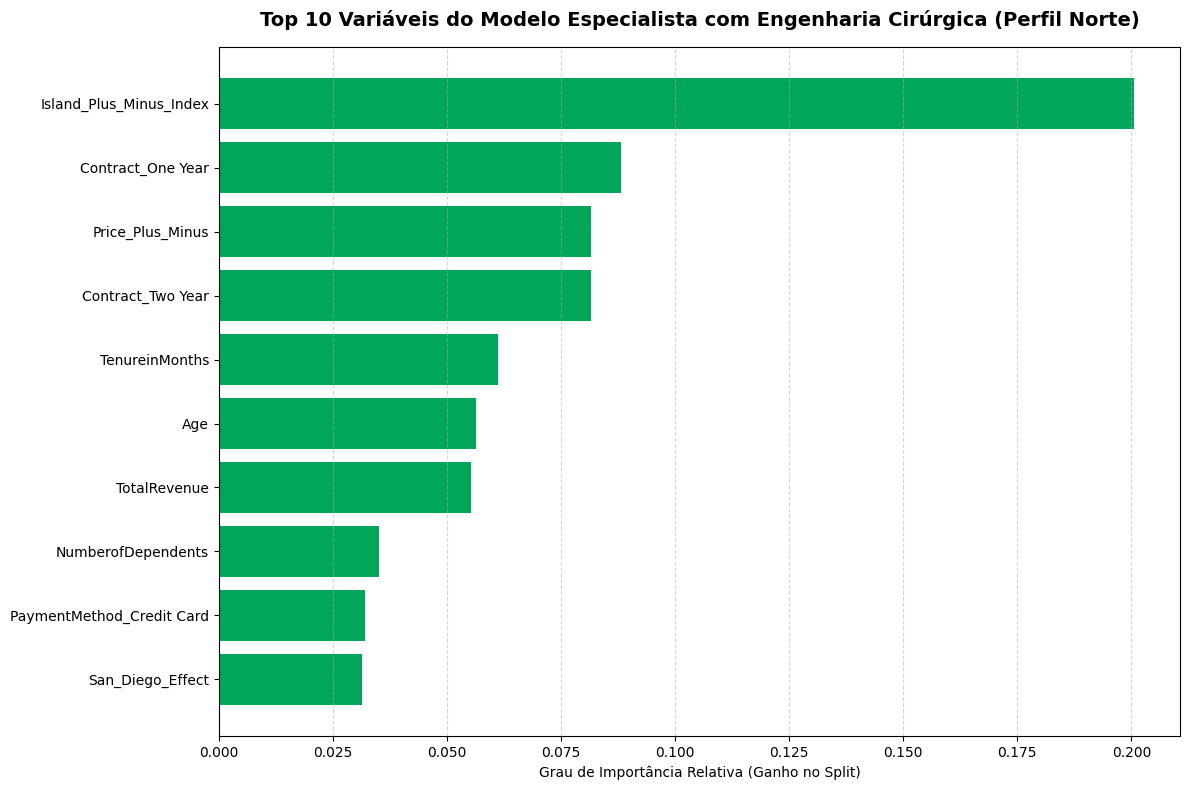


--- Top 5 Variáveis do Modelo Vencedor ---
                    Feature  Importance
18  Island_Plus_Minus_Index    0.200623
43        Contract_One Year    0.088228
16         Price_Plus_Minus    0.081617
44        Contract_Two Year    0.081457
4            TenureinMonths    0.061110


In [10]:
# =========================================================================
# 6. TREINAMENTO DO XGBOOST ESPECIALISTA COM VALIDAÇÃO CRUZADA
# =========================================================================
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity', 'X_som', 'Y_som'
]

X_norte_fe = regiao_norte.drop(columns=vazamentos_e_ruidos)
y_norte_fe = np.where(regiao_norte['CustomerStatus'] == 'Churned', 1, 0)

cols_cat_fe = X_norte_fe.select_dtypes(include=['object', 'category']).columns.tolist()
X_norte_fe_encoded = pd.get_dummies(X_norte_fe, columns=cols_cat_fe, drop_first=True)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_norte_fe_encoded, y_norte_fe, test_size=0.3, random_state=42, stratify=y_norte_fe
)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'gamma': [1, 2, 3]
}

proporcao_classes = (len(y_train_fe) - sum(y_train_fe)) / sum(y_train_fe)
xgb_base_fe = XGBClassifier(scale_pos_weight=proporcao_classes, eval_metric='logloss', random_state=42)

grid_search_fe = GridSearchCV(
    estimator=xgb_base_fe, param_grid=param_grid, scoring='recall', cv=5, verbose=0, n_jobs=-1
)
grid_search_fe.fit(X_train_fe, y_train_fe)

# =========================================================================
# 7. PERFORMANCE FINAL E GRÁFICO DE IMPORTÂNCIA DE VARIÁVEIS
# =========================================================================
best_xgb_fe = grid_search_fe.best_estimator_
y_pred_fe = best_xgb_fe.predict(X_test_fe)
y_prob_fe = best_xgb_fe.predict_proba(X_test_fe)[:, 1]

print("\n=================== PERFORMANCE DO MODELO FINAL EVOLUÍDO ===================")
print(f"Melhores parâmetros: {grid_search_fe.best_params_}")
print(f"ROC-AUC Atualizado: {roc_auc_score(y_test_fe, y_prob_fe)*100:.2f}%")
print(f"RECALL Atualizado: {recall_score(y_test_fe, y_pred_fe)*100:.2f}%")
print(f"PRECISÃO Atualizada: {precision_score(y_test_fe, y_pred_fe)*100:.2f}%")

print("\nNova Matriz de Confusão:")
cm_fe = confusion_matrix(y_test_fe, y_pred_fe)
print(f"  [Clientes do Norte que FICARAM previstos corretamente]: {cm_fe[0][0]}")
print(f"  [Clientes do Norte que FICARAM mas gerou Alarme Falso]: {cm_fe[0][1]}")
print(f"  [Clientes do Norte que REALMENTE CANCELARAM e cometeu Erro Crítico]: {cm_fe[1][0]}")
print(f"  [Clientes do Norte que REALMENTE CANCELARAM previstos corretamente]: {cm_fe[1][1]}")

# Gráfico 6: Importância de Variáveis do Modelo Vencedor
df_importances_otimizado = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Importance': best_xgb_fe.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(df_importances_otimizado['Feature'].head(10)[::-1], df_importances_otimizado['Importance'].head(10)[::-1], color='#00a65a')
plt.xlabel('Grau de Importância Relativa (Ganho no Split)')
plt.title('Top 10 Variáveis do Modelo Especialista com Engenharia Cirúrgica (Perfil Norte)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Top 5 Variáveis do Modelo Vencedor ---")
print(df_importances_otimizado.head(5))

In [14]:
print("=================== DIAGNÓSTICO DE ENGENHARIA REVERSA (PERFIL SUL) ===================")

# 1. Isolando o hemisfério sul de risco a partir da sua matriz de análise
regiao_sul = df_analise[df_analise['Y_som'] < 20].copy()
total_sul = regiao_sul.shape[0]

print(f"Total de Clientes localizados no Perfil Sul (Y < 20): {total_sul}")

# 2. Calculando a Taxa Base de Churn no Sul
total_churn_sul = regiao_sul[regiao_sul['CustomerStatus'] == 'Churned'].shape[0]
taxa_churn_sul = (total_churn_sul / total_sul) * 100
print(f"Total de Cancelamentos no Sul: {total_churn_sul} ({taxa_churn_sul:.2f}%)")
print("-" * 60)

# 3. Principais Motivos de Churn relatados no Sul
print("--- 1. Principais Motivos de Churn no Perfil Sul (Top 5) ---")
if 'ChurnReason' in regiao_sul.columns:
    print(regiao_sul[regiao_sul['CustomerStatus'] == 'Churned']['ChurnReason'].value_counts().head(5))
else:
    print("Coluna ChurnReason não encontrada.")
print("-" * 60)

# 4. Comportamento Financeiro (Preço Mensal)
print("--- 2. Comparativo de Cobrança Mensal (MonthlyCharge) ---")
media_churn_sul = regiao_sul[regiao_sul['CustomerStatus'] == 'Churned']['MonthlyCharge'].mean()
media_stay_sul = regiao_sul[regiao_sul['CustomerStatus'] == 'Stayed']['MonthlyCharge'].mean()
mediana_churn_sul = regiao_sul[regiao_sul['CustomerStatus'] == 'Churned']['MonthlyCharge'].median()

print(f"Média de quem CANCELOU no Sul: ${media_churn_sul:.2f}")
print(f"Média de quem FICOU no Sul:    ${media_stay_sul:.2f}")
print(f"Mediana de quem CANCELOU no Sul: ${mediana_churn_sul:.2f}")
print("-" * 60)

# 5. Distribuição de Ofertas de Entrada no Sul
print("--- 3. Distribuição de Ofertas entre os Cancelados do Sul ---")
if 'Offer' in regiao_sul.columns:
    print(regiao_sul[regiao_sul['CustomerStatus'] == 'Churned']['Offer'].value_counts())

=================== DIAGNÓSTICO DE ENGENHARIA REVERSA (PERFIL SUL) ===================
Total de Clientes localizados no Perfil Sul (Y < 20): 2992
Total de Cancelamentos no Sul: 324 (10.83%)
------------------------------------------------------------
--- 1. Principais Motivos de Churn no Perfil Sul (Top 5) ---
ChurnReason
Competitor made better offer     49
Competitor had better devices    48
Attitude of support person       35
Don't know                       28
Competitor offered more data     26
Name: count, dtype: int64
------------------------------------------------------------
--- 2. Comparativo de Cobrança Mensal (MonthlyCharge) ---
Média de quem CANCELOU no Sul: $71.52
Média de quem FICOU no Sul:    $62.83
Mediana de quem CANCELOU no Sul: $79.68
------------------------------------------------------------
--- 3. Distribuição de Ofertas entre os Cancelados do Sul ---
Offer
No Offer    178
Offer B      54
Offer E      36
Offer A      27
Offer C      15
Offer D      14
Name: coun

In [18]:
print("=================== RAIO-X DIRETO: IMPACTO DE OFERTAS NO SUL ===================")

# 1. Garantindo que estamos olhando para os clientes de internet do Sul
df_internet_sul = regiao_sul[regiao_sul['InternetService'] == 'Yes'].copy()

# 2. Tabela Cruzada: Oferta vs Status do Cliente (Volume Absoluto)
print("--- 1. Volume de Clientes por Oferta no Sul ---")
tabela_ofertas = pd.crosstab(df_internet_sul['Offer'], df_internet_sul['CustomerStatus'], margins=True)
print(tabela_ofertas)
print("-" * 60)

# 3. Taxa de Churn Real por Tipo de Oferta
print("--- 2. Taxa de Churn Real por Oferta (Ordenado pelo Pior Cenário) ---")
taxa_churn_oferta = pd.crosstab(df_internet_sul['Offer'], df_internet_sul['CustomerStatus'], normalize='index')
if 'Churned' in taxa_churn_oferta.columns:
    taxa_churn_oferta['Taxa_Churn'] = (taxa_churn_oferta['Churned'] * 100).round(1)
    print(taxa_churn_oferta[['Taxa_Churn']].sort_values(by='Taxa_Churn', ascending=False))
else:
    print("Nenhum churn detectado nessa quebra.")
print("-" * 60)

# 4. O Cruzamento de Ouro: Oferta + Contrato
print("--- 3. Onde o perigo mora: Oferta vs Tipo de Contrato ---")
oferta_contrato = pd.crosstab(
    df_internet_sul['Offer'], 
    [df_internet_sul['Contract'], df_internet_sul['CustomerStatus']],
    normalize='index'
) * 100
print(oferta_contrato.round(1).astype(str) + '%')

=================== RAIO-X DIRETO: IMPACTO DE OFERTAS NO SUL ===================
--- 1. Volume de Clientes por Oferta no Sul ---
CustomerStatus  Churned  Joined  Stayed   All
Offer                                        
No Offer            163      14     940  1117
Offer A              27       0     348   375
Offer B              52       0     363   415
Offer C              14       0      80    94
Offer D              11       0      64    75
Offer E              28      17      31    76
All                 295      31    1826  2152
------------------------------------------------------------
--- 2. Taxa de Churn Real por Oferta (Ordenado pelo Pior Cenário) ---
CustomerStatus  Taxa_Churn
Offer                     
Offer E               36.8
Offer C               14.9
Offer D               14.7
No Offer              14.6
Offer B               12.5
Offer A                7.2
------------------------------------------------------------
--- 3. Onde o perigo mora: Oferta vs Tipo de Cont

=================== ESTEIRA ESPECIALISTA: HEMISFÉRIO SUL EXPERT ===================
Features 'Island_Plus_Minus_Index' e 'Offer_Contract_Vulnerability' amarradas com sucesso!
Iniciando treinamento real no Sul com Validação Cruzada (5-Folds)...

=================== PERFORMANCE DO MODELO SUL EVOLUÍDO ===================
Melhores parâmetros: {'gamma': 1, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100}
ROC-AUC Atualizado: 93.39%
RECALL Atualizado: 90.72%
PRECISÃO Atualizada: 43.78%

Nova Matriz de Confusão (Sul):
  [Clientes do Sul que FICARAM previstos corretamente]: 688
  [Clientes do Sul que FICARAM mas gerou Alarme Falso]: 113
  [Clientes do Sul que REALMENTE CANCELARAM e cometeu Erro Crítico]: 9
  [Clientes do Sul que REALMENTE CANCELARAM previstos corretamente]: 88


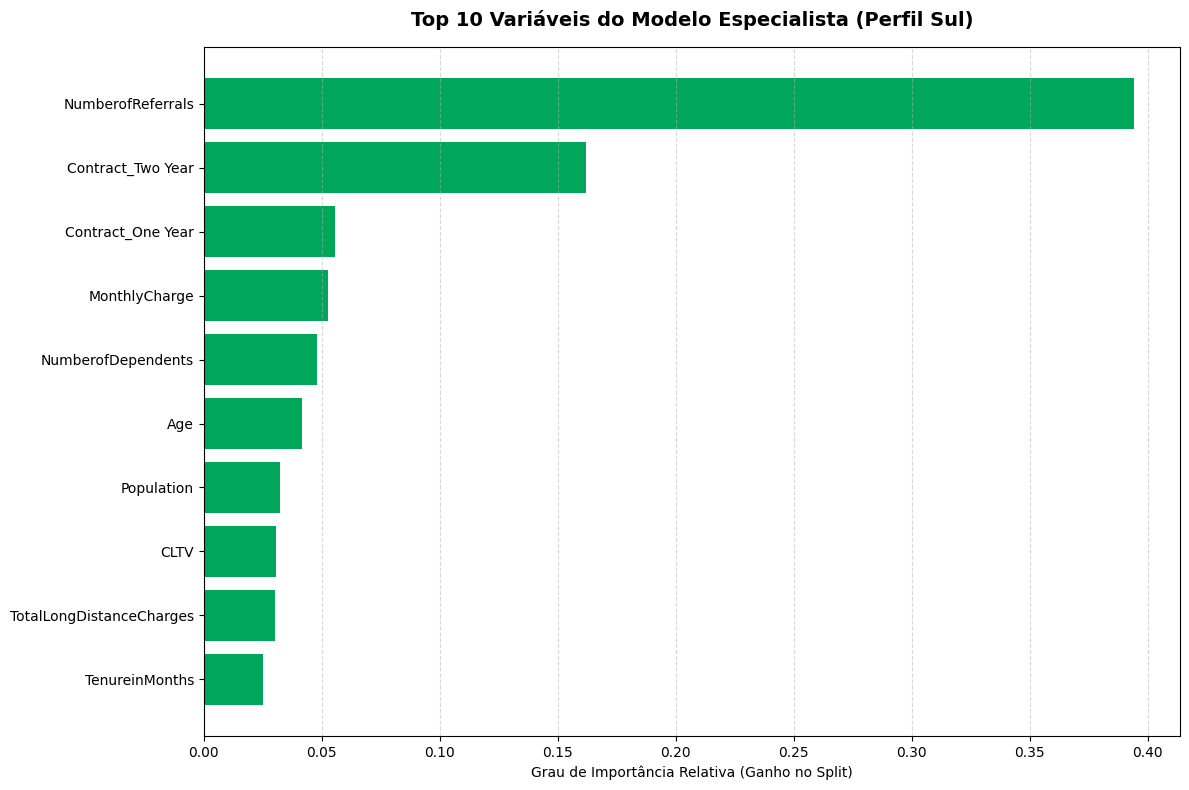


--- Top 5 Variáveis do Modelo Vencedor (Sul) ---
               Feature  Importance
3    NumberofReferrals    0.393909
37   Contract_Two Year    0.161782
36   Contract_One Year    0.055557
7        MonthlyCharge    0.052420
1   NumberofDependents    0.047763


In [25]:
print("=================== ESTEIRA ESPECIALISTA: HEMISFÉRIO SUL EXPERT ===================")

# 1. Isolando o hemisfério sul de risco baseado na sua lógica do Kohonen
df_sul_laboratorio = df_analise[df_analise['Y_som'] < 20].copy()

# =========================================================================
# PASSO A: CONSTRUÇÃO DAS FEATURES ESPECIALISTAS DO SUL (PLUS-MINUS + OFERTAS)
# =========================================================================
servicos_dbscan = ['DeviceProtectionPlan', 'PremiumTechSupport', 'UnlimitedData']
df_dbscan_sul = df_sul_laboratorio[servicos_dbscan].copy()

for col in servicos_dbscan:
    df_dbscan_sul[col] = np.where(df_dbscan_sul[col] == 'Yes', 1, 0)

scaler_sul = StandardScaler()
X_sul_scaled = scaler_sul.fit_transform(df_dbscan_sul)

# 1. Plus-Minus de Ilha (Mantendo a fundação estável)
dbscan_sul = DBSCAN(eps=1.0, min_samples=15)
df_sul_laboratorio['Ilha_Sul_Expandida'] = dbscan_sul.fit_predict(X_sul_scaled)
mapa_medias_ilhas_sul = df_sul_laboratorio.groupby('Ilha_Sul_Expandida')['MonthlyCharge'].mean().to_dict()
df_sul_laboratorio['Island_Mean_Price_Sul'] = df_sul_laboratorio['Ilha_Sul_Expandida'].map(mapa_medias_ilhas_sul)
df_sul_laboratorio['Price_Plus_Minus'] = df_sul_laboratorio['MonthlyCharge'] - df_sul_laboratorio['Island_Mean_Price_Sul']

cushion_suporte = np.where(df_sul_laboratorio['PremiumTechSupport'] == 'Yes', -5.0, 0.0)
cushion_protecao = np.where(df_sul_laboratorio['DeviceProtectionPlan'] == 'Yes', -3.0, 0.0)
cushion_dados = np.where(df_sul_laboratorio['UnlimitedData'] == 'Yes', -1.0, 0.0)
df_sul_laboratorio['Service_Cushion'] = cushion_suporte + cushion_protecao + cushion_dados
df_sul_laboratorio['Island_Plus_Minus_Index'] = df_sul_laboratorio['Price_Plus_Minus'] + df_sul_laboratorio['Service_Cushion']

# 2. ENGENHARIA CIRÚRGICA DE OFERTAS (O insight das tabelas de contingência)
# Se está na Offer E, C ou D E no contrato Month-to-Month, a vulnerabilidade vai para o teto
condicao_vulneravel = (
    df_sul_laboratorio['Offer'].isin(['Offer E', 'Offer C', 'Offer D']) & 
    (df_sul_laboratorio['Contract'] == 'Month-to-month')
)
df_sul_laboratorio['Offer_Contract_Vulnerability'] = np.where(condicao_vulneravel, 1, 0)

# Modificador regional
df_sul_laboratorio['San_Diego_Effect'] = np.where(df_sul_laboratorio['City'] == 'San Diego', 1, 0)

print("Features 'Island_Plus_Minus_Index' e 'Offer_Contract_Vulnerability' amarradas com sucesso!")

# =========================================================================
# PASSO B: TRATAMENTO E BLOQUEIO DE LEAKAGE (Offer REMOVIDA DO DROP)
# =========================================================================
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity', 'X_som', 'Y_som', 'Ilha_Sul_Expandida',
    'Island_Mean_Price_Sul', 'Price_Plus_Minus', 'Service_Cushion'
]
# NOTA: Deixamos 'Offer' fora da lista negra para o XGBoost usar as outras ofertas se quiser refinamento

vazamentos_reais = [c for c in vazamentos_e_ruidos if c in df_sul_laboratorio.columns]
X_sul_fe = df_sul_laboratorio.drop(columns=vazamentos_reais)
y_sul_fe = np.where(df_sul_laboratorio['CustomerStatus'] == 'Churned', 1, 0)

# =========================================================================
# PASSO B: TRATAMENTO E BLOQUEIO DE LEAKAGE (LISTA NEGRA HERDADA)
# =========================================================================
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity', 'X_som', 'Y_som', 'Ilha_Sul_Expandida',
    'Island_Mean_Price_Sul', 'Price_Plus_Minus', 'Service_Cushion', 'Offer' # Offer fora por enquanto
]

# Garantindo drop seguro apenas de colunas existentes
vazamentos_reais = [c for c in vazamentos_e_ruidos if c in df_sul_laboratorio.columns]

X_sul_fe = df_sul_laboratorio.drop(columns=vazamentos_reais)
y_sul_fe = np.where(df_sul_laboratorio['CustomerStatus'] == 'Churned', 1, 0)

# Dummificação das categóricas remanescentes
cols_cat_fe = X_sul_fe.select_dtypes(include=['object', 'category']).columns.tolist()
X_sul_fe_encoded = pd.get_dummies(X_sul_fe, columns=cols_cat_fe, drop_first=True)

# Split 70/30 Estratificado por causa do desbalanço do Sul
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_sul_fe_encoded, y_sul_fe, test_size=0.3, random_state=42, stratify=y_sul_fe
)

# =========================================================================
# PASSO C: TUNING DO XGBOOST SUL COM POS_WEIGHT ADAPTADO
# =========================================================================
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'gamma': [1, 2, 3]
}

# Peso dinâmico calculado com as amostras do Sul
proporcao_classes_sul = (len(y_train_fe) - sum(y_train_fe)) / sum(y_train_fe)
xgb_base_fe = XGBClassifier(scale_pos_weight=proporcao_classes_sul, eval_metric='logloss', random_state=42)

grid_search_fe = GridSearchCV(
    estimator=xgb_base_fe, param_grid=param_grid, scoring='recall', cv=5, verbose=0, n_jobs=-1
)

print("Iniciando treinamento real no Sul com Validação Cruzada (5-Folds)...")
grid_search_fe.fit(X_train_fe, y_train_fe)

# =========================================================================
# PASSO D: PERFORMANCE E PLOT DA IMPORTÂNCIA
# =========================================================================
best_xgb_fe = grid_search_fe.best_estimator_
y_pred_fe = best_xgb_fe.predict(X_test_fe)
y_prob_fe = best_xgb_fe.predict_proba(X_test_fe)[:, 1]

print("\n=================== PERFORMANCE DO MODELO SUL EVOLUÍDO ===================")
print(f"Melhores parâmetros: {grid_search_fe.best_params_}")
print(f"ROC-AUC Atualizado: {roc_auc_score(y_test_fe, y_prob_fe)*100:.2f}%")
print(f"RECALL Atualizado: {recall_score(y_test_fe, y_pred_fe)*100:.2f}%")
print(f"PRECISÃO Atualizada: {precision_score(y_test_fe, y_pred_fe)*100:.2f}%")

print("\nNova Matriz de Confusão (Sul):")
cm_fe = confusion_matrix(y_test_fe, y_pred_fe)
print(f"  [Clientes do Sul que FICARAM previstos corretamente]: {cm_fe[0][0]}")
print(f"  [Clientes do Sul que FICARAM mas gerou Alarme Falso]: {cm_fe[0][1]}")
print(f"  [Clientes do Sul que REALMENTE CANCELARAM e cometeu Erro Crítico]: {cm_fe[1][0]}")
print(f"  [Clientes do Sul que REALMENTE CANCELARAM previstos corretamente]: {cm_fe[1][1]}")

# Gráfico de Importância de Variáveis do Sul
df_importances_otimizado = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Importance': best_xgb_fe.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(df_importances_otimizado['Feature'].head(10)[::-1], df_importances_otimizado['Importance'].head(10)[::-1], color='#00a65a')
plt.xlabel('Grau de Importância Relativa (Ganho no Split)')
plt.title('Top 10 Variáveis do Modelo Especialista (Perfil Sul)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Top 5 Variáveis do Modelo Vencedor (Sul) ---")
print(df_importances_otimizado.head(5))

=================== MODELO CAMPEÃO: GLOBAL ORIGINAL SECO ===================
Treinando XGBoost Global em 4930 amostras brutas...

=================== PERFORMANCE DO MODELO GLOBAL ORIGINAL ===================
Melhores parâmetros encontrados: {'gamma': 1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
ROC-AUC Global: 90.65%
RECALL Global:  90.37%
PRECISÃO Global: 56.21%

Matriz de Confusão Global Seca:
  [Clientes que FICARAM previstos corretamente]: 1157
  [Clientes que FICARAM mas gerou Alarme Falso]: 395
  [Clientes que REALMENTE CANCELARAM e cometeu Erro Crítico]: 54
  [Clientes que REALMENTE CANCELARAM previstos corretamente]: 507


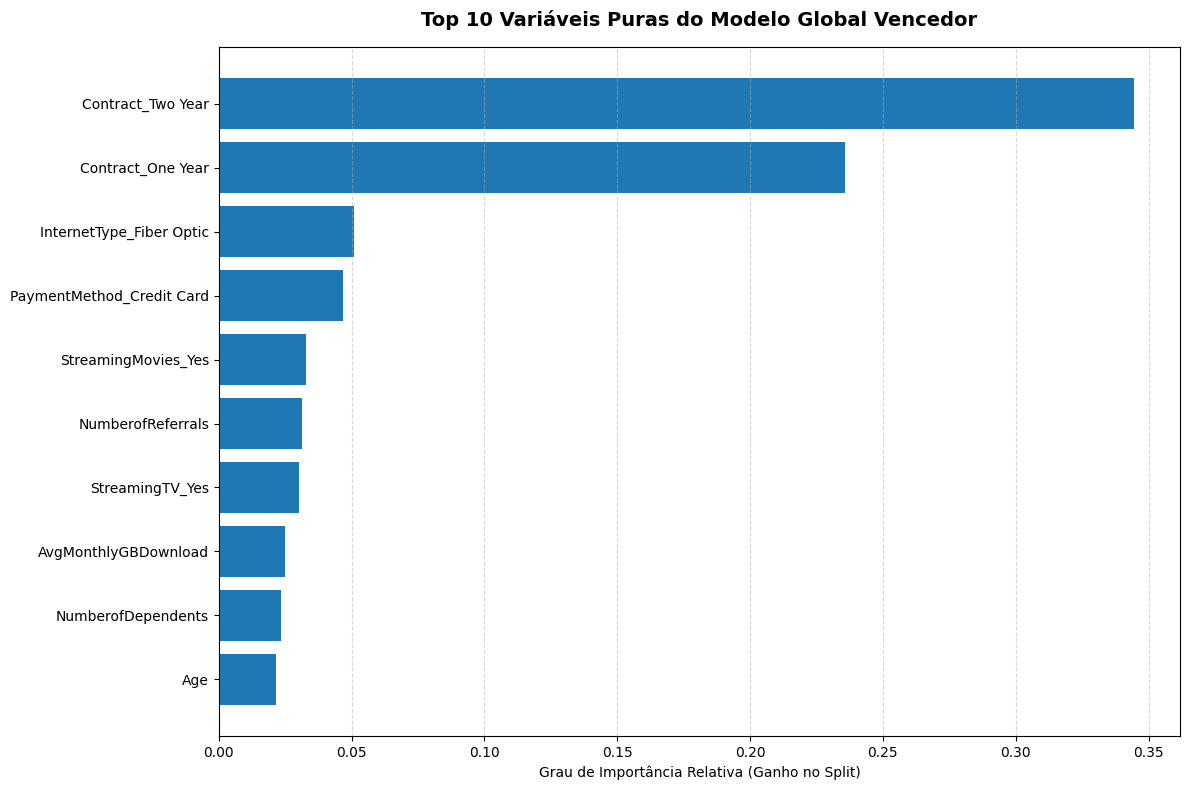


--- Top 5 Variáveis Decisivas do Modelo de Produção ---
                      Feature  Importance
39          Contract_Two Year    0.344619
38          Contract_One Year    0.235849
29   InternetType_Fiber Optic    0.050798
41  PaymentMethod_Credit Card    0.046923
35        StreamingMovies_Yes    0.032794


In [40]:
print("=================== MODELO CAMPEÃO: GLOBAL ORIGINAL SECO ===================")

# 1. Partindo do df original bruto e saneado
df_global = df.copy()

# =========================================================================
# PASSO A: FAXINA DE VAZAMENTOS E COLUNAS DE CONTROLE (SEM PLUS-MINUS)
# =========================================================================
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity'
]

# Removendo os vazamentos reais para criar a matriz de recursos preditores X
vazamentos_reais = [c for c in vazamentos_e_ruidos if c in df_global.columns]
X_global = df_global.drop(columns=vazamentos_reais, errors='ignore')

# Definição do vetor do alvo original (Label numérico mapeado 0 e 1)
y_bruto = df_global['ChurnLabel'].values

# Dummificação das categóricas remanescentes da base original
cols_cat_global = X_global.select_dtypes(include=['object', 'category']).columns.tolist()
X_global_encoded = pd.get_dummies(X_global, columns=cols_cat_global, drop_first=True)

# Split 70/30 Estratificado idêntico para manter o rigor de validação
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_global_encoded, y_bruto, test_size=0.3, random_state=42, stratify=y_bruto
)

# =========================================================================
# PASSO B: TUNING DO MODELO GLOBAL COM SCALE_POS_WEIGHT
# =========================================================================
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'gamma': [1, 2, 3]
}

# Peso dinâmico calculado com base no desbalanço da base original completa
proporcao_global = (len(y_train_g) - sum(y_train_g)) / sum(y_train_g)
xgb_global_base = XGBClassifier(scale_pos_weight=proporcao_global, eval_metric='logloss', random_state=42)

print(f"Treinando XGBoost Global em {X_train_g.shape[0]} amostras brutas...")
grid_search_global = GridSearchCV(
    estimator=xgb_global_base, param_grid=param_grid, scoring='recall', cv=5, verbose=0, n_jobs=-1
)
grid_search_global.fit(X_train_g, y_train_g)

# =========================================================================
# PASSO C: DIAGNÓSTICO DE PERFORMANCE DE PRODUÇÃO
# =========================================================================
best_xgb_global = grid_search_global.best_estimator_
y_pred_g = best_xgb_global.predict(X_test_g)
y_prob_g = best_xgb_global.predict_proba(X_test_g)[:, 1]

print("\n=================== PERFORMANCE DO MODELO GLOBAL ORIGINAL ===================")
print(f"Melhores parâmetros encontrados: {grid_search_global.best_params_}")
print(f"ROC-AUC Global: {roc_auc_score(y_test_g, y_prob_g)*100:.2f}%")
print(f"RECALL Global:  {recall_score(y_test_g, y_pred_g)*100:.2f}%")
print(f"PRECISÃO Global: {precision_score(y_test_g, y_pred_g)*100:.2f}%")

print("\nMatriz de Confusão Global Seca:")
cm_g = confusion_matrix(y_test_g, y_pred_g)
print(f"  [Clientes que FICARAM previstos corretamente]: {cm_g[0][0]}")
print(f"  [Clientes que FICARAM mas gerou Alarme Falso]: {cm_g[0][1]}")
print(f"  [Clientes que REALMENTE CANCELARAM e cometeu Erro Crítico]: {cm_g[1][0]}")
print(f"  [Clientes que REALMENTE CANCELARAM previstos corretamente]: {cm_g[1][1]}")

# Gráfico de Importância das Variáveis Reais de Produção
df_imp_global = pd.DataFrame({
    'Feature': X_train_g.columns,
    'Importance': best_xgb_global.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(df_imp_global['Feature'].head(10)[::-1], df_imp_global['Importance'].head(10)[::-1], color='#1f77b4')
plt.xlabel('Grau de Importância Relativa (Ganho no Split)')
plt.title('Top 10 Variáveis Puras do Modelo Global Vencedor', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Top 5 Variáveis Decisivas do Modelo de Produção ---")
print(df_imp_global.head(5))